# Занятие. Реальный датасет из интернета: базовый финансовый анализ акций Apple

## Зачем этот ноутбук

В этом ноутбуке мы работаем с **реальным финансовым датасетом из интернета**.  
Мы будем анализировать исторические биржевые данные по акциям Apple и учиться превращать «сырые» котировки в понятные выводы.

В таблице есть ключевые финансовые поля:

- `open` — цена открытия торгового дня;
- `high` — максимальная цена за день;
- `low` — минимальная цена за день;
- `close` — цена закрытия;
- `volume` — объём торгов;
- `adjusted` — скорректированная цена, которую часто используют для анализа динамики.

## Чему учится студент

После выполнения ноутбука вы поймёте:

- как загружать **внешний CSV-датасет по URL**;
- как читать финансовую таблицу и распознавать типичные биржевые поля;
- как считать простые финансовые показатели:
  - дневную доходность;
  - дневной торговый диапазон;
  - скользящие средние;
  - волатильность;
- как делать выводы по графикам и таблицам;
- как использовать подобный подход в собственном дипломном проекте.

## Источник данных

Мы используем публичный CSV-файл с историческими котировками Apple, доступный по прямой ссылке в интернете.

## Практическая ячейка 1. Импорт библиотек и загрузка финансового датасета по URL

### Назначение ячейки
Эта ячейка:
- подключает библиотеки `pandas` и `matplotlib`;
- задаёт ссылку на внешний CSV-файл;
- загружает таблицу в `DataFrame`;
- приводит столбцы к более удобным именам;
- показывает первые строки данных.

### Краткая теория
`DataFrame` — это основная табличная структура библиотеки `pandas`.  
Именно в `DataFrame` удобно хранить финансовые данные: даты, цены, объёмы торгов, вычисленные показатели.

Финансовые датасеты часто загружаются в формате **CSV**.  
CSV — это обычный текстовый файл, где:
- каждая строка — это одна запись;
- столбцы разделены запятыми;
- первая строка обычно содержит заголовки.

### Что важно понять по результату
После запуска вы увидите:
- первые строки таблицы;
- откуда именно были загружены данные;
- сколько строк и столбцов есть в датасете.

Если интернет в момент запуска недоступен, ноутбук попробует открыть локальную копию файла.  
Это полезный приём для устойчивого учебного проекта.

### Какие функции используются
- `pd.read_csv()` — читать CSV-файл;
- `pd.to_datetime()` — переводить текстовую дату в формат даты;
- `sort_values()` — сортировать строки;
- `reset_index()` — перенумеровать строки после сортировки.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

dataset_url = "https://raw.githubusercontent.com/plotly/datasets/master/finance-charts-apple.csv"
local_fallback = "finance-charts-apple.csv"

try:
    df = pd.read_csv(dataset_url)
    data_source = f"Данные загружены из интернета: {dataset_url}"
except Exception:
    df = pd.read_csv(local_fallback)
    data_source = f"Интернет недоступен, загружена локальная копия: {local_fallback}"

rename_map = {
    "AAPL.Open": "open",
    "AAPL.High": "high",
    "AAPL.Low": "low",
    "AAPL.Close": "close",
    "AAPL.Volume": "volume",
    "AAPL.Adjusted": "adjusted"
}

df = df.rename(columns=rename_map)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

display(df.head())
print(data_source)
print(f"Размер таблицы: {df.shape[0]} строк, {df.shape[1]} столбцов")

,Date,open,high,low,close,volume,adjusted,dn,mavg,up,direction
0,2015-02-17,127.489998,128.880005,126.919998,127.830002,63152400,122.905254,106.741052,117.927667,129.114281,Increasing
1,2015-02-18,127.629997,128.779999,127.449997,128.720001,44891700,123.760965,107.842423,118.940333,130.038244,Increasing
2,2015-02-19,128.479996,129.029999,128.330002,128.449997,37362400,123.501363,108.894245,119.889167,130.884089,Decreasing
3,2015-02-20,128.619995,129.500000,128.050003,129.500000,48948400,124.510914,109.785449,120.763500,131.741551,Increasing
4,2015-02-23,130.020004,133.000000,129.660004,133.000000,70974100,127.876074,110.372516,121.720167,133.067817,Increasing


Интернет недоступен, загружена локальная копия: finance-charts-apple.csv
Размер таблицы: 506 строк, 11 столбцов


## Практическая ячейка 2. Первичный обзор финансовых данных

### Назначение ячейки
Эта ячейка помогает быстро понять структуру датасета:
- какие есть столбцы;
- какие у них типы данных;
- есть ли пропуски;
- за какой период собраны данные;
- как выглядят базовые статистики по ценам и объёму.

### Краткая теория
Перед любым анализом данных нужно выполнить **первичный аудит** таблицы.

Почему это важно:
- если тип данных неправильный, расчёты могут дать ошибку;
- если есть пропуски, часть формул будет работать некорректно;
- если вы не знаете временной диапазон, выводы будут неполными.

Для финансовых данных особенно важно проверить:
- дату начала и конца периода;
- диапазоны цен;
- размер объёма торгов;
- наличие пустых значений.

### Что важно понять по результату
После запуска обратите внимание:
- столбец `Date` должен иметь тип даты;
- цены и объёмы должны быть числовыми;
- пропусков лучше не иметь, либо понимать, как они появились;
- `describe()` покажет минимумы, максимумы и средние значения.

Это первый шаг к профессиональному анализу:  
сначала понять таблицу, потом строить выводы.

### Какие функции используются
- `df.columns.tolist()` — получить список названий столбцов;
- `df.dtypes` — посмотреть типы данных;
- `df.isna().sum()` — посчитать пропуски;
- `describe()` — вывести описательную статистику.

In [2]:
main_cols = ["Date", "open", "high", "low", "close", "volume", "adjusted"]

print("Названия столбцов:")
print(df.columns.tolist())

print("\nТипы данных:")
print(df[main_cols].dtypes)

print("\nКоличество пропусков:")
print(df[main_cols].isna().sum())

print("\nПериод наблюдений:")
print("Начало:", df["Date"].min().date())
print("Конец :", df["Date"].max().date())

print("\nОписательная статистика по ключевым числовым полям:")
display(df[["open", "high", "low", "close", "volume", "adjusted"]].describe().round(2))

Названия столбцов:
['Date', 'open', 'high', 'low', 'close', 'volume', 'adjusted', 'dn', 'mavg', 'up', 'direction']

Типы данных:
Date        datetime64[us]
open               float64
high               float64
low                float64
close              float64
volume               int64
adjusted           float64
dtype: object

Количество пропусков:
Date        0
open        0
high        0
low         0
close       0
volume      0
adjusted    0
dtype: int64

Период наблюдений:
Начало: 2015-02-17
Конец : 2017-02-16

Описательная статистика по ключевым числовым полям:


,open,high,low,close,volume,adjusted
count,506.00,506.00,506.00,506.00,5.060000e+02,506.00
mean,112.93,113.92,111.94,112.96,4.317842e+07,110.46
std,11.29,11.25,11.26,11.24,1.985253e+07,10.54
min,90.00,91.67,89.47,90.34,1.147590e+07,89.01
25%,105.48,106.35,104.66,105.67,2.974240e+07,103.48
50%,112.89,114.15,111.80,113.03,3.747460e+07,110.82
75%,122.27,123.50,121.60,122.18,5.076395e+07,119.26
max,135.67,136.27,134.84,135.51,1.622063e+08,135.51


## Практическая ячейка 3. Подготовка данных и вычисление финансовых признаков

### Назначение ячейки
Теперь мы создаём новые столбцы, которые часто используются в финансовом анализе:
- дневную доходность;
- дневной диапазон колебания цены;
- объём торгов в миллионах;
- короткую и длинную скользящую среднюю.

### Краткая теория
**Дневная доходность** показывает, насколько изменилась цена относительно предыдущего дня.  
Это один из самых базовых показателей динамики актива.

Формула:
`доходность = (текущая цена - предыдущая цена) / предыдущая цена`

**Торговый диапазон** показывает, насколько сильно цена «ходила» внутри одного дня.  
Если диапазон большой, день был более напряжённым и изменчивым.

**Скользящая средняя** — это среднее значение цены за последние несколько дней.
Она помогает:
- сгладить резкие скачки;
- увидеть общий тренд;
- сравнивать краткосрочную и более устойчивую динамику.

### Что важно понять по результату
После выполнения вы заметите:
- в первой строке доходность будет пустой (`NaN`), потому что не с чем сравнивать;
- в первых строках длинной скользящей средней тоже будут пустые значения — ещё не накопилось достаточно дней;
- новые столбцы делают исходную таблицу более полезной для анализа и визуализации.

### Какие функции используются
- `pct_change()` — относительное изменение между соседними строками;
- `rolling().mean()` — скользящее среднее;
- арифметические операции над столбцами `DataFrame`.

In [3]:
df["daily_return_pct"] = df["adjusted"].pct_change() * 100
df["range_pct"] = (df["high"] - df["low"]) / df["open"] * 100
df["volume_mln"] = df["volume"] / 1_000_000
df["ma_5"] = df["adjusted"].rolling(window=5).mean()
df["ma_20"] = df["adjusted"].rolling(window=20).mean()

feature_cols = ["Date", "adjusted", "daily_return_pct", "range_pct", "volume_mln", "ma_5", "ma_20"]
display(df[feature_cols].head(10).round(3))

print("Пустые значения после создания новых признаков:")
print(df[feature_cols].isna().sum())

C:\Users\User\AppData\Local\Temp\ipykernel_43480\3194959415.py:8: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(df[feature_cols].head(10).round(3))


,Date,adjusted,daily_return_pct,range_pct,volume_mln,ma_5,ma_20
0,2015-02-17,122.905,NaN,1.537,63.152,NaN,NaN
1,2015-02-18,123.761,0.696,1.042,44.892,NaN,NaN
2,2015-02-19,123.501,-0.210,0.545,37.362,NaN,NaN
3,2015-02-20,124.511,0.817,1.127,48.948,NaN,NaN
4,2015-02-23,127.876,2.703,2.569,70.974,124.511,NaN
5,2015-02-24,127.078,-0.624,1.828,69.228,125.345,NaN
6,2015-02-25,123.828,-2.557,2.622,74.712,125.359,NaN
7,2015-02-26,125.395,1.266,3.308,91.288,125.738,NaN
8,2015-02-27,123.511,-1.503,1.792,62.015,125.538,NaN
9,2015-03-02,124.117,0.490,1.532,48.097,124.786,NaN


Пустые значения после создания новых признаков:
Date                 0
adjusted             0
daily_return_pct     1
range_pct            0
volume_mln           0
ma_5                 4
ma_20               19
dtype: int64


## Практическая ячейка 4. Базовый финансовый анализ: доходность, волатильность и месячные показатели

### Назначение ячейки
Эта ячейка переводит таблицу в осмысленные финансовые показатели:
- среднюю дневную доходность;
- волатильность;
- долю дней роста;
- дни с минимальной и максимальной ценой;
- месячные агрегаты по цене и объёму.

### Краткая теория
**Волатильность** — это степень изменчивости цены.  
Чем выше волатильность, тем сильнее актив колеблется и тем менее он стабилен в краткосрочном периоде.

В самом простом учебном варианте волатильность можно оценивать через
**стандартное отклонение дневной доходности**.

Также в финансовом анализе полезно строить **агрегации по месяцам**:
- средняя цена за месяц;
- суммарный объём торгов;
- сравнение месяцев между собой.

Это помогает увидеть картину не по отдельным дням, а по более крупным периодам.

### Что важно понять по результату
После запуска:
- вы получите компактную сводку по главным метрикам;
- увидите лучший и худший дни по цене;
- увидите месяцы с наибольшей средней ценой и наибольшим объёмом торгов.

Это уже не просто «таблица котировок», а **первичный финансовый отчёт**.

### Какие функции используются
- `mean()` — среднее значение;
- `std()` — стандартное отклонение;
- `idxmin()` / `idxmax()` — индексы минимального и максимального значения;
- `resample("M")` — группировка по месяцам.

In [4]:
valid_returns = df["daily_return_pct"].dropna()

min_price_row = df.loc[df["adjusted"].idxmin()]
max_price_row = df.loc[df["adjusted"].idxmax()]

summary_df = pd.DataFrame({
    "Показатель": [
        "Средняя дневная доходность, %",
        "Волатильность (std дневной доходности), %",
        "Доля дней роста, %",
        "Минимальная скорректированная цена",
        "Максимальная скорректированная цена",
        "Средний дневной объём торгов, млн"
    ],
    "Значение": [
        round(valid_returns.mean(), 3),
        round(valid_returns.std(), 3),
        round((valid_returns > 0).mean() * 100, 2),
        round(min_price_row["adjusted"], 3),
        round(max_price_row["adjusted"], 3),
        round(df["volume_mln"].mean(), 3)
    ],
    "Комментарий": [
        "Среднее изменение цены относительно предыдущего дня",
        "Чем больше значение, тем выше изменчивость актива",
        "Сколько торговых дней завершились ростом",
        f"Дата минимума: {min_price_row['Date'].date()}",
        f"Дата максимума: {max_price_row['Date'].date()}",
        "Средний объём сделок в миллионах акций"
    ]
})

monthly_stats = (
    df.set_index("Date")
      .resample("M")
      .agg(
          avg_close=("close", "mean"),
          avg_adjusted=("adjusted", "mean"),
          total_volume=("volume", "sum")
      )
)

monthly_stats["total_volume_mln"] = monthly_stats["total_volume"] / 1_000_000
monthly_stats["month"] = monthly_stats.index.strftime("%Y-%m")

best_month_price = monthly_stats.loc[monthly_stats["avg_adjusted"].idxmax()]
best_month_volume = monthly_stats.loc[monthly_stats["total_volume"].idxmax()]

display(summary_df)
print("\nПоследние 6 месяцев в агрегированном виде:")
display(monthly_stats[["month", "avg_close", "avg_adjusted", "total_volume_mln"]].tail(6).round(2))

print(f"Месяц с наибольшей средней скорректированной ценой: {best_month_price['month']}")
print(f"Месяц с наибольшим суммарным объёмом торгов: {best_month_volume['month']}")

ValueError: Invalid frequency: M. Failed to parse with error message: ValueError("'M' is no longer supported for offsets. Please use 'ME' instead.")

## Практическая ячейка 5. Визуализация финансовых данных

### Назначение ячейки
Здесь мы переводим числовые показатели в графики:
1. график цены и скользящих средних;
2. гистограмму дневной доходности;
3. график среднемесячной цены.

### Краткая теория
В финансовом анализе график часто даёт понимание быстрее, чем таблица.

**Линейный график цены** помогает увидеть тренд.  
Если короткая скользящая средняя находится выше длинной, это может говорить о более сильной краткосрочной динамике.

**Гистограмма доходности** показывает, как распределяются дневные изменения:
- около нуля — спокойные дни;
- большие отклонения — более резкие движения.

**Месячный график** позволяет увидеть укрупнённую картину и убрать лишний шум ежедневных колебаний.

### Что важно понять по результату
После выполнения:
- вы увидите, где цена росла, а где снижалась;
- сможете оценить, насколько часто встречаются резкие дневные изменения;
- сравните ежедневный и месячный уровень анализа.

### Какие функции используются
- `plt.figure()` — создать новый график;
- `plt.plot()` — линейный график;
- `plt.hist()` — гистограмма;
- `plt.grid()` — сетка для удобства чтения графика.

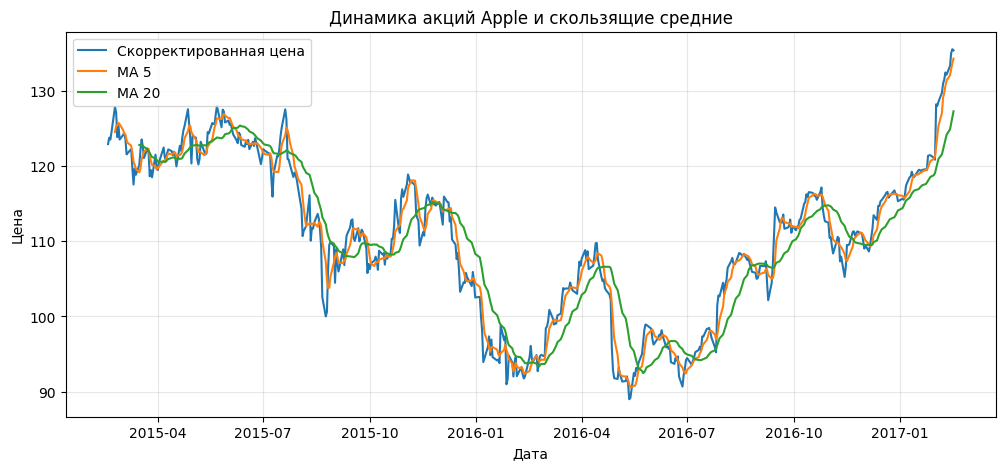

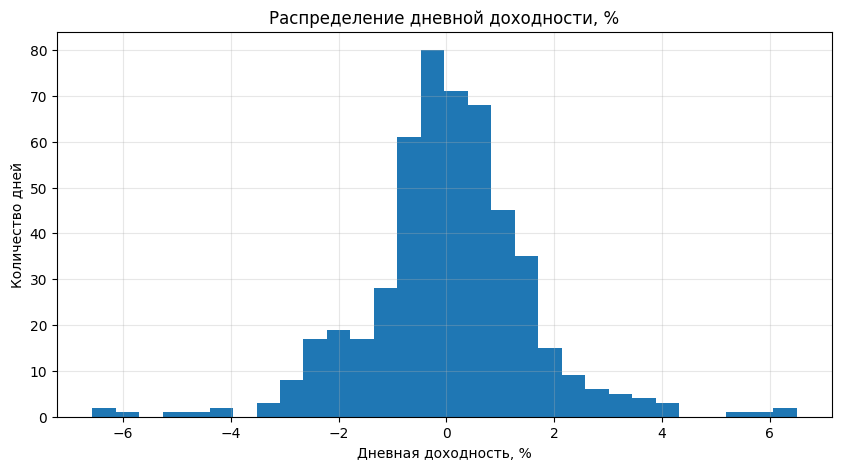

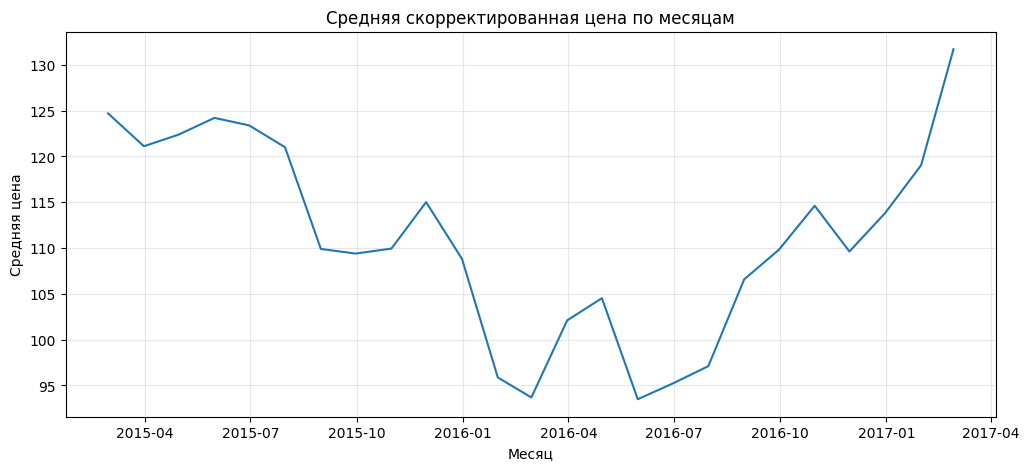

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["adjusted"], label="Скорректированная цена")
plt.plot(df["Date"], df["ma_5"], label="MA 5")
plt.plot(df["Date"], df["ma_20"], label="MA 20")
plt.title("Динамика акций Apple и скользящие средние")
plt.xlabel("Дата")
plt.ylabel("Цена")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(valid_returns, bins=30)
plt.title("Распределение дневной доходности, %")
plt.xlabel("Дневная доходность, %")
plt.ylabel("Количество дней")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(monthly_stats.index, monthly_stats["avg_adjusted"])
plt.title("Средняя скорректированная цена по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Средняя цена")
plt.grid(alpha=0.3)
plt.show()

## Практическая ячейка 6. Итоговые выводы и мост к дипломному проекту

### Назначение ячейки
Последняя практическая ячейка:
- превращает расчёты в понятные текстовые выводы;
- показывает, как аналитик формулирует результат обычным языком;
- добавляет `assert`-проверки, чтобы ноутбук было удобно запускать через **Run all**.

### Краткая теория
Хороший анализ состоит не только из вычислений.  
Очень важно уметь ответить на вопросы:

- что произошло с данными;
- какие показатели оказались ключевыми;
- как это можно использовать в прикладной задаче.

`assert` — это простая проверка условий в Python.  
Если условие ложно, программа остановится с ошибкой.  
Это удобно для учебных ноутбуков: студент сразу видит, что что-то пошло не так.

### Что важно понять по результату
После запуска вы получите несколько финальных выводов:
- где был максимум и минимум цены;
- насколько актив был изменчив;
- какая краткосрочная тенденция наблюдается на конце ряда;
- как такой шаблон можно перенести в дипломный проект.

### Идея для диплома
По аналогии можно сделать:
- анализ акций нескольких компаний;
- анализ криптовалют;
- анализ валютных курсов;
- мини-сервис финансового мониторинга с автоматическим отчётом и графиками.

In [ ]:
latest_row = df.iloc[-1]
trend_text = (
    "краткосрочная средняя выше долгосрочной, значит краткосрочный тренд выглядит сильнее"
    if latest_row["ma_5"] > latest_row["ma_20"]
    else "краткосрочная средняя ниже долгосрочной, значит краткосрочный тренд выглядит слабее"
)

largest_move_row = df.loc[df["daily_return_pct"].abs().idxmax()]

print("ИТОГОВЫЕ ВЫВОДЫ")
print(f"1. Минимальная скорректированная цена была {min_price_row['adjusted']:.2f} и наблюдалась {min_price_row['Date'].date()}.")
print(f"2. Максимальная скорректированная цена была {max_price_row['adjusted']:.2f} и наблюдалась {max_price_row['Date'].date()}.")
print(f"3. Средняя дневная доходность составила {valid_returns.mean():.3f}%.")
print(f"4. Волатильность по дневной доходности составила {valid_returns.std():.3f}%.")
print(f"5. Самое сильное дневное движение было {largest_move_row['daily_return_pct']:.3f}% в дату {largest_move_row['Date'].date()}.")
print(f"6. На последней дате анализа {trend_text}.")

assert "Date" in df.columns
assert all(col in df.columns for col in ["open", "high", "low", "close", "volume", "adjusted"])
assert all(col in df.columns for col in ["daily_return_pct", "range_pct", "volume_mln", "ma_5", "ma_20"])
assert df["Date"].is_monotonic_increasing
assert df["adjusted"].notna().all()
assert valid_returns.shape[0] > 0

print("\nПроверки assert пройдены успешно. Ноутбук корректно выполняется целиком через Run all.")

ИТОГОВЫЕ ВЫВОДЫ
1. Минимальная скорректированная цена была 89.01 и наблюдалась 2016-05-12.
2. Максимальная скорректированная цена была 135.51 и наблюдалась 2017-02-15.
3. Средняя дневная доходность составила 0.031%.
4. Волатильность по дневной доходности составила 1.529%.
5. Самое сильное дневное движение было -6.571% в дату 2016-01-27.
6. На последней дате анализа краткосрочная средняя выше долгосрочной, значит краткосрочный тренд выглядит сильнее.

Проверки assert пройдены успешно. Ноутбук корректно выполняется целиком через Run all.


## Что студент должен вынести из этого занятия

После выполнения ноутбука вы должны понимать:

- финансовый датасет можно загрузить напрямую из интернета по URL;
- перед анализом обязательно нужно проверить типы данных, пропуски и временной диапазон;
- из цен акций можно вычислять новые полезные признаки;
- графики помогают увидеть тренд, изменчивость и структуру доходностей;
- хороший анализ заканчивается не графиком, а **понятным выводом**.

## Что можно улучшить дальше

Следующие шаги для развития темы:

1. сравнить Apple с другими компаниями;
2. добавить анализ нескольких тикеров;
3. посчитать накопленную доходность;
4. построить корреляции между активами;
5. сделать веб-приложение с автоматической загрузкой и визуализацией финансовых данных.

## Связь с дипломным проектом

Этот шаблон легко переносится в дипломную работу:
- в desktop-приложение на Python;
- в web-приложение с графиками;
- в Telegram-бота с финансовой аналитикой;
- в систему мониторинга данных для бизнеса.